In [1]:
%%capture
%load_ext autoreload
%autoreload 2

%matplotlib inline

# To publish: jupyter nbconvert --to pdf --template citations.tplx --TemplateExporter.exclude_input=True final_report_sleep.ipynb

In [2]:
# Import local modules

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# An Exploration of Sleep

In [3]:
%%capture
# Author: Sayan Faraz <sayan.faraz@mail.utoronto.ca>
# Starter code: https://mne.tools/dev/auto_tutorials/sample-datasets/plot_sleep.html
# Starter code authors: Alexandre Gramfort <alexandre.gramfort@inria.fr>
#                       Stanislas Chambon <stan.chambon@gmail.com>
#                       Joan Massich <mailsik@gmail.com>
# License: BSD 3 clause

import os
import os.path as op

# from download import download

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mne
import pprint

from scipy import signal

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

import src.utils.preprocess as preprocess
import src.utils.consts as consts
import src.utils.data_objs as data_objs

# from mne.time_frequency import psd_welch
# from mne_features.feature_extraction import FeatureExtractor

sns.set(font="Arial")
sns.set_context("talk", font_scale=1.2)

default_figsize = (20, 4)

plt.rcParams["figure.figsize"] = default_figsize

pd.set_option('display.notebook_repr_html', True)
def _repr_latex_(self):
    return "\centering{%s}" % self.to_latex()
pd.DataFrame._repr_latex_ = _repr_latex_

print(__doc__)

In [4]:
RAND_STATE_INT = 10
rng = np.random.default_rng()

In [5]:
%%capture
# SETUP
# Note: the following code is sourced from the starter code, and is used for setup only.

SUBJECT = [0]
RECORDINGS=[1]

EPOCH_DURATION = 30.

sleep_subj_0 = data_objs.SleepSubject(subject=0, epoch_duration=EPOCH_DURATION)
subj_0_recording_1 = sleep_subj_0.get_recording(1)

In [6]:
subj_0_recording_2 = sleep_subj_0.get_recording(2)

Using default location ~/mne_data for PHYSIONET_SLEEP...
Extracting EDF parameters from C:\Users\sayan\mne_data\physionet-sleep-data\SC4002E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


c:\Users\sayan\CodingProjects\sleep-data-analysis\src\utils\preprocess.py:15: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(subject_files[0])
c:\Users\sayan\CodingProjects\sleep-data-analysis\src\utils\preprocess.py:15: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(subject_files[0])
c:\Users\sayan\CodingProjects\sleep-data-analysis\src\utils\preprocess.py:15: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(subject_files[0])
c:\Users\sayan\CodingProjects\sleep-data-analysis\src\utils\preprocess.py:23: RuntimeWarning: The unit for channel(s) EMG submental, Event marker, Resp oro-nasal, Temp rectal has changed from V to NA.
  raw.set_channel_types(mapping)


Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Not setting metadata
1307 matching events found
No baseline correction applied
0 projection items activated


In [7]:
print(subj_0_recording_1.raw.info['sfreq'])
print(subj_0_recording_1.sfreq)

100.0
100.0


In [8]:
# print(subj_0_recording_0.raw.info['sfreq'])
# print(subj_0_recording_0.sfreq)

In [9]:
fpz_ch = [subj_0_recording_1.raw.ch_names.index('EEG Fpz-Cz')]
eeg, t = subj_0_recording_1.raw[fpz_ch]

eeg = eeg / 1e-6 # EEG is typically measured in microvolts

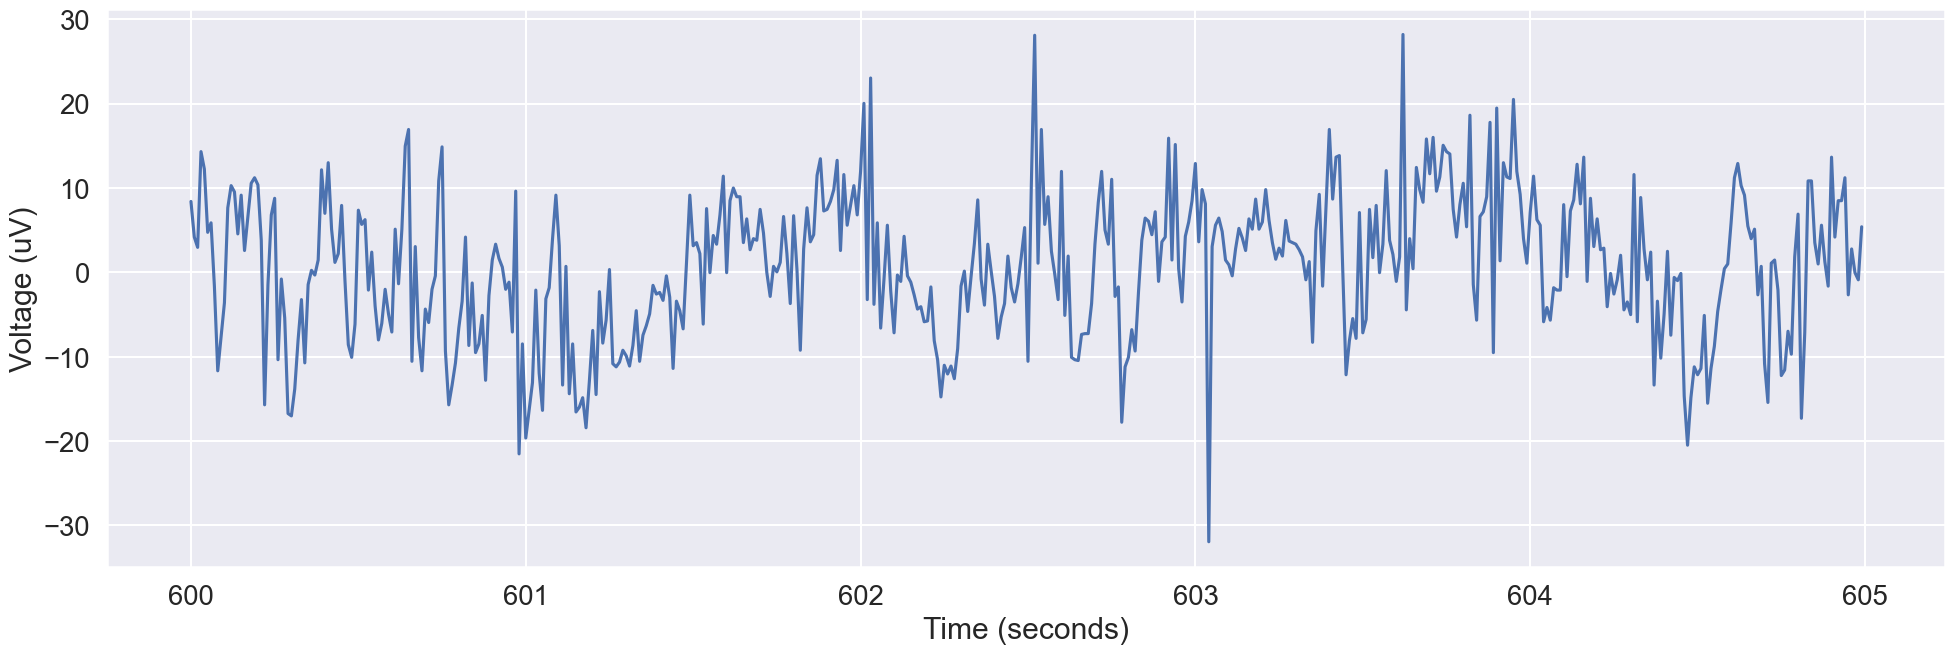

In [10]:
plt.rcParams["figure.figsize"] = (20, 7)
plt.rcParams['axes.titlepad'] = 20

rand_s, rand_e = preprocess.inds(start=600, duration=5, sfreq=subj_0_recording_1.sfreq)

plt.plot(t[rand_s:rand_e], (eeg.T)[rand_s:rand_e])
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (uV)")

plt.tight_layout()

plt.rcParams["figure.figsize"] = default_figsize

***Figure 1:*** It's really hard to tell what's happening in raw EEG

In [11]:
w_s, w_e = preprocess.inds(start=500, duration=5, sfreq=subj_0_recording_1.sfreq)
sl_s, sl_e = preprocess.inds(start=35000, duration=5, sfreq=subj_0_recording_1.sfreq)
rem_s, rem_e = preprocess.inds(start=45100, duration=5, sfreq=subj_0_recording_1.sfreq)

In this notebook, I thought it would be fun to look at all these different characteristics in EEG. I'll extract power spectral features from sleep EEG data provided with the MNE EEG processing library, and compare them amongst different stages of sleep.<cite data-cite="kemp_analysis_2000"></cite><cite data-cite="goldberger_physiobank_2000"></cite><cite data-cite="chambon_deep_2018"></cite><cite data-cite="mne_sleep"></cite> These features include relative and absolute power distribution amongst frequency bands relevant to neuroscience, and total power output in EEG in different brain states.

## Our Game Plan

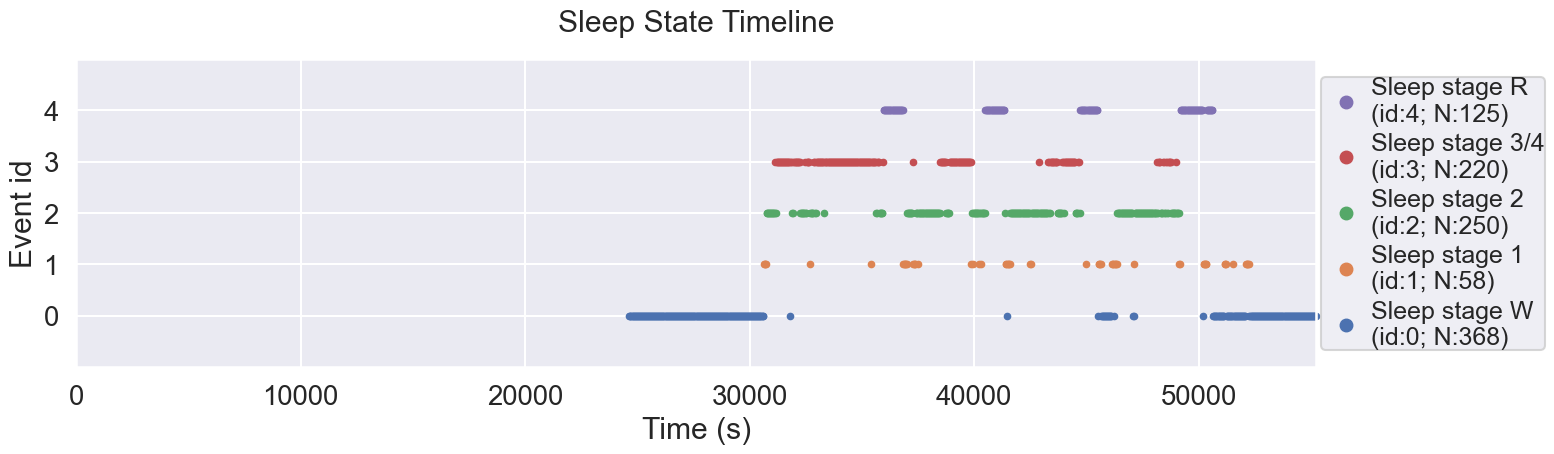

In [12]:
# FROM STARTER CODE
ax = plt.axes()
ax.set_title("Sleep State Timeline")
mne.viz.plot_events(subj_0_recording_1.events, event_id=consts.get_event_ids(),
                    sfreq=subj_0_recording_1.sfreq, axes=ax)

# keep the color-code for further plotting
stage_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# plt.rcParams["figure.figsize"] = default_figsize

***Figure 3:*** Sleep stages, as annotated through manual polysomnography. These annotations are used as ground-truth values for this report's analysis.

## Plotting time

You can really start seeing the differences between the stages here! Stage III/IV barely has any non-delta activity, while REM sleep and wakeful states have much lower delta activity. There's a surprising amunt of alpha in the REM sleep sample which is interesting as well.

All of this was just from one sample though! Let's see if we can see similar patterns in a boxlot:

In [13]:
%%capture

sleep_stage_rel_bandpower, sleep_stage_abs_bandpower = preprocess.bandpowers_from_epochs(
    subj_0_recording_1.epochs,
    subj_0_recording_1.raw,
    consts.get_event_ids(),
    subj_0_recording_1.sfreq,
    channel='EEG Fpz-Cz'
)

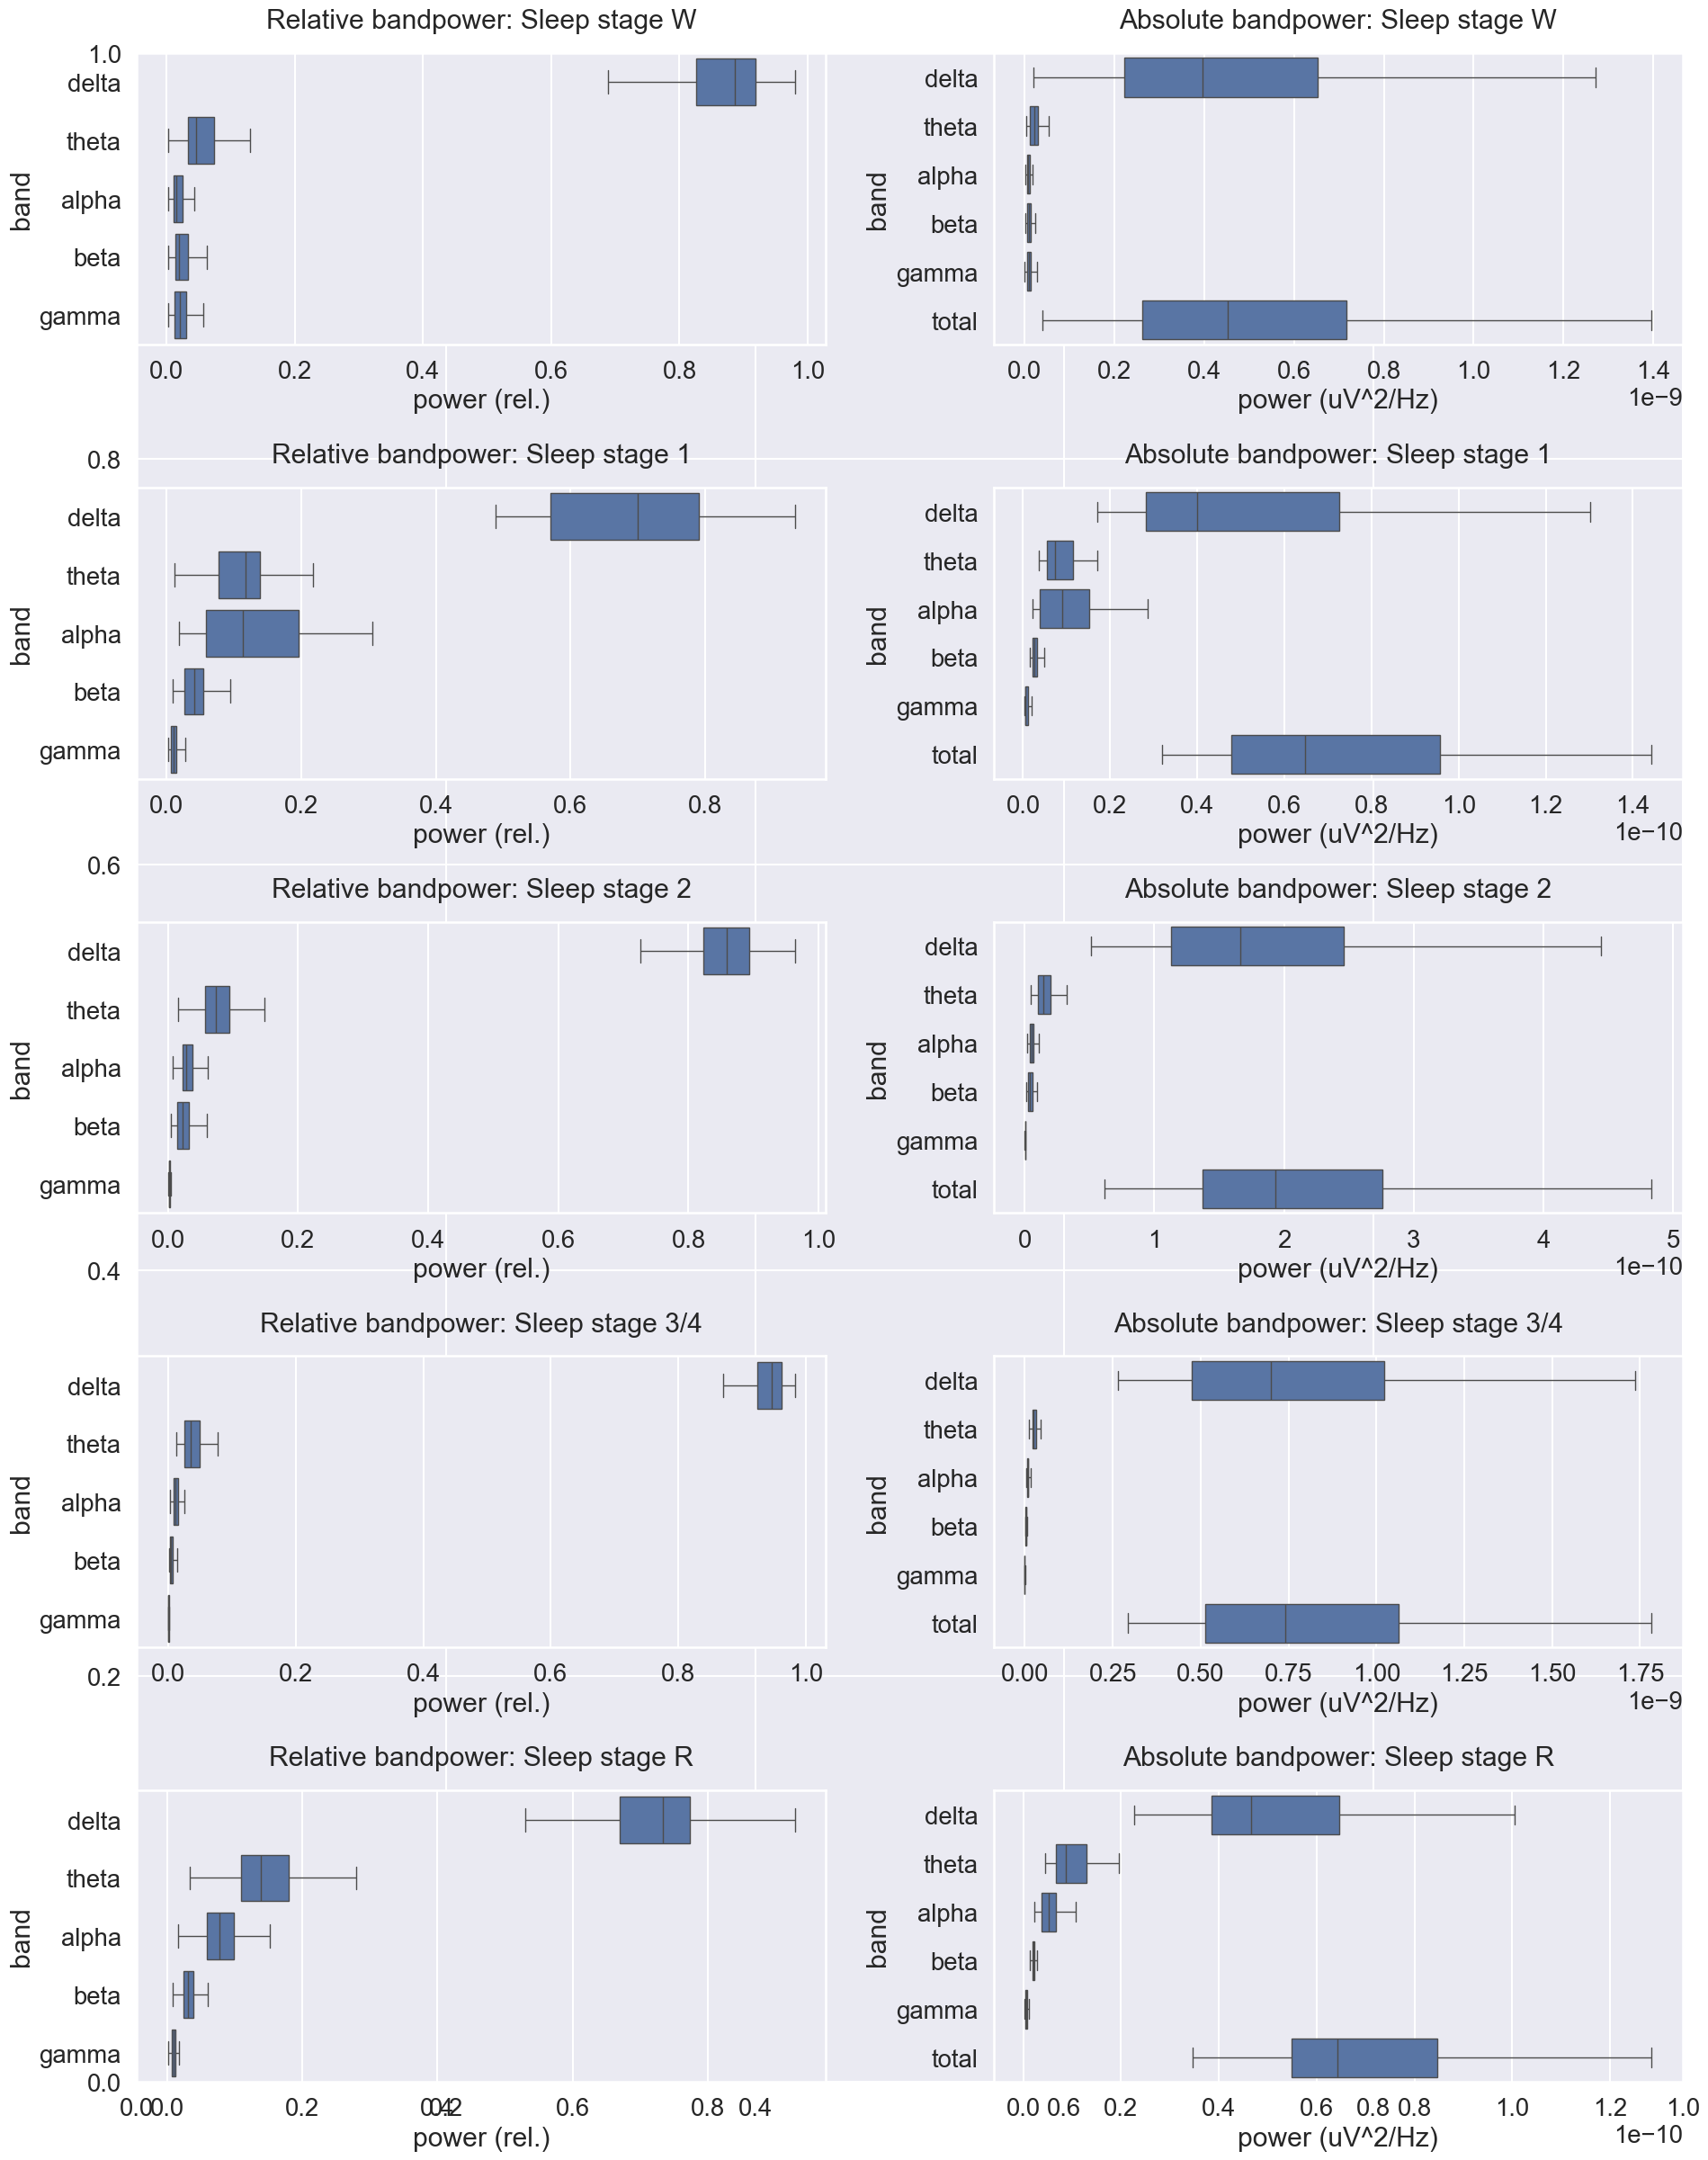

In [14]:
plt.rcParams["figure.figsize"] = (20,25)
plt.subplot()

nrows = len(consts.get_event_ids().keys())
ncols = 2
subplot_count = 1

for event, e_id  in consts.get_event_ids().items():
    sub_epoch_pow_rel_df = pd.DataFrame.from_dict(sleep_stage_rel_bandpower[event]).melt().rename(columns={'variable': 'band', 'value': 'power (rel.)'})
    sub_epoch_pow_abs_df = pd.DataFrame.from_dict(sleep_stage_abs_bandpower[event]).melt().rename(columns={'variable': 'band', 'value': 'power (uV^2/Hz)'})

    # subplot_id = str(len(event_id.keys())) + "2" + str(subplot_count)
    plt.subplot(nrows, ncols, subplot_count)
    sns.boxplot(x='power (rel.)', y='band', data=sub_epoch_pow_rel_df, showfliers = False)# , scale="width")
    plt.title("Relative bandpower: " + event)

    subplot_count += 1

    # subplot_id = str(len(event_id.keys())) + "2" + str(subplot_count)
    plt.subplot(nrows, ncols, subplot_count)
    sns.boxplot(x='power (uV^2/Hz)', y='band', data=sub_epoch_pow_abs_df, showfliers = False) #, scale="width")
    plt.title("Absolute bandpower: " + event)

    subplot_count += 1

plt.tight_layout()

***Figure 8:*** Boxplot of relative and absolute bandpowers in different sleep stages.

And here's a 5-number summary for good measure:

In [15]:
five_num_summ_file = open('five_num_summ_file.txt', 'w') 

five_num_summary_rel_bpwr = preprocess.bandpower_five_num_summary(sleep_stage_rel_bandpower)
five_num_summary_abs_bpwr = preprocess.bandpower_five_num_summary(sleep_stage_abs_bandpower)

print("RELATIVE BANDPOWER: 5-NUM SUMMARY\n", pprint.pformat(five_num_summary_rel_bpwr, indent=2), file=five_num_summ_file)

print("ABSOLUTE BANDPOWER: 5-NUM SUMMARY\n", pprint.pformat(five_num_summary_abs_bpwr, indent=2), file=five_num_summ_file)

five_num_summ_file.close()

In [16]:
pd.set_option("display.precision", 7)

five_num_summary_rel_bpwr_df = pd.DataFrame.from_dict({(i,j): five_num_summary_rel_bpwr[i][j] 
                           for i in five_num_summary_rel_bpwr.keys() 
                           for j in five_num_summary_rel_bpwr[i].keys()},
                       orient='index')

five_num_summary_rel_bpwr_df = five_num_summary_rel_bpwr_df.rename_axis("Percentile", axis="columns")
five_num_summary_rel_bpwr_df = five_num_summary_rel_bpwr_df.rename_axis(["Sleep Stage", "Freq. Band"], axis="index")

five_num_summary_rel_bpwr_df = five_num_summary_rel_bpwr_df.drop(labels="# of Outliers (lower)", axis="columns")
five_num_summary_rel_bpwr_df = five_num_summary_rel_bpwr_df.drop(labels="# of Outliers (upper)", axis="columns")

pd.set_option('display.max_columns', None)
five_num_summary_rel_bpwr_df.T

Sleep Stage Sleep stage W                                              \
Freq. Band          delta      theta      alpha       beta      gamma   
Percentile                                                              
0%              0.6884717  0.0031782  0.0029774  0.0032812  0.0032164   
25%             0.8260379  0.0335748  0.0112189  0.0135014  0.0123352   
50%             0.8863260  0.0463505  0.0151196  0.0197471  0.0203929   
75%             0.9188992  0.0743164  0.0254910  0.0332953  0.0314970   
100%            0.9795428  0.1308866  0.0438728  0.0629006  0.0577866   

Sleep Stage Sleep stage 1                                              \
Freq. Band          delta      theta      alpha       beta      gamma   
Percentile                                                              
0%              0.4885020  0.0120696  0.0188894  0.0094236  0.0027531   
25%             0.5702042  0.0769274  0.0582174  0.0272456  0.0062098   
50%             0.7002084  0.1176802  0.1136302  0.0410284  0.0108200   
75%             0.7898479  0.1384654  0.1957155  0.0544473  0.0152100   
100%            0.9327185  0.2172067  0.3051789  0.0945365  0.0277267   

Sleep Stage Sleep stage 2                                              \
Freq. Band          delta      theta      alpha       beta      gamma   
Percentile                                                              
0%              0.7258765  0.0156990  0.0071793  0.0046207  0.0005187   
25%             0.8234017  0.0568090  0.0222580  0.0144680  0.0013829   
50%             0.8590158  0.0738697  0.0282225  0.0231674  0.0021950   
75%             0.8930255  0.0946414  0.0379173  0.0327650  0.0030137   
100%            0.9631485  0.1485523  0.0606103  0.0591644  0.0051771   

Sleep Stage Sleep stage 3/4                                              \
Freq. Band            delta      theta      alpha       beta      gamma   
Percentile                                                                
0%                0.8705669  0.0119656  0.0033001  0.0007926  0.0001299   
25%               0.9239109  0.0246740  0.0081123  0.0027941  0.0002860   
50%               0.9467868  0.0346516  0.0107740  0.0045866  0.0004589   
75%               0.9614450  0.0491860  0.0151210  0.0073946  0.0007951   
100%              0.9825070  0.0776022  0.0252343  0.0137594  0.0015578   

Sleep Stage Sleep stage R                                              
Freq. Band          delta      theta      alpha       beta      gamma  
Percentile                                                             
0%              0.5303529  0.0329826  0.0158663  0.0077827  0.0014326  
25%             0.6701612  0.1089704  0.0580252  0.0239561  0.0071518  
50%             0.7331680  0.1378100  0.0768633  0.0308743  0.0095155  
75%             0.7740475  0.1801050  0.0982622  0.0386300  0.0120029  
100%            0.9288889  0.2793487  0.1521215  0.0605414  0.0178297

***Table 1:*** 5-number summary for relative bandpowers in each stage of sleep.

In [17]:
pd.set_option("display.precision", 2)

five_num_summary_abs_bpwr_df = pd.DataFrame.from_dict({(i,j): five_num_summary_abs_bpwr[i][j] 
                           for i in five_num_summary_abs_bpwr.keys() 
                           for j in five_num_summary_abs_bpwr[i].keys()},
                       orient='index')

five_num_summary_abs_bpwr_df = five_num_summary_abs_bpwr_df.rename_axis("Percentile", axis="columns")
five_num_summary_abs_bpwr_df = five_num_summary_abs_bpwr_df.rename_axis(["Sleep Stage", "Freq. Band"], axis="index")

five_num_summary_abs_bpwr_df = five_num_summary_abs_bpwr_df.drop(labels="# of Outliers (lower)", axis="columns")
five_num_summary_abs_bpwr_df = five_num_summary_abs_bpwr_df.drop(labels="# of Outliers (upper)", axis="columns")

pd.set_option('display.max_columns', None)
five_num_summary_abs_bpwr_df.T

Sleep Stage Sleep stage W                                                    \
Freq. Band          delta     theta     alpha      beta     gamma     total   
Percentile                                                                    
0%               2.04e-11  3.96e-12  2.30e-12  1.69e-12  5.05e-13  3.91e-11   
25%              2.23e-10  1.26e-11  5.74e-12  5.37e-12  5.96e-12  2.63e-10   
50%              3.96e-10  2.09e-11  7.99e-12  8.76e-12  1.03e-11  4.52e-10   
75%              6.52e-10  2.98e-11  1.07e-11  1.29e-11  1.47e-11  7.18e-10   
100%             1.27e-09  5.36e-11  1.82e-11  2.38e-11  2.76e-11  1.40e-09   

Sleep Stage Sleep stage 1                                                    \
Freq. Band          delta     theta     alpha      beta     gamma     total   
Percentile                                                                    
0%               1.70e-11  3.61e-12  2.07e-12  1.62e-12  4.01e-13  3.20e-11   
25%              2.83e-11  5.42e-12  3.84e-12  2.13e-12  4.98e-13  4.78e-11   
50%              4.00e-11  7.40e-12  8.96e-12  2.61e-12  5.93e-13  6.48e-11   
75%              7.26e-11  1.14e-11  1.52e-11  3.30e-12  1.07e-12  9.56e-11   
100%             1.30e-10  1.70e-11  2.85e-11  4.85e-12  1.91e-12  1.44e-10   

Sleep Stage Sleep stage 2                                                    \
Freq. Band          delta     theta     alpha      beta     gamma     total   
Percentile                                                                    
0%               5.16e-11  4.81e-12  2.23e-12  1.55e-12  2.48e-13  6.16e-11   
25%              1.13e-10  1.06e-11  4.41e-12  2.94e-12  3.47e-13  1.37e-10   
50%              1.67e-10  1.42e-11  5.39e-12  4.32e-12  3.90e-13  1.93e-10   
75%              2.46e-10  1.97e-11  7.23e-12  6.04e-12  4.41e-13  2.75e-10   
100%             4.45e-10  3.25e-11  1.12e-11  9.97e-12  5.76e-13  4.83e-10   

Sleep Stage Sleep stage 3/4                                                    \
Freq. Band            delta     theta     alpha      beta     gamma     total   
Percentile                                                                      
0%                 2.65e-10  1.28e-11  4.04e-12  1.38e-12  1.92e-13  2.93e-10   
25%                4.75e-10  2.15e-11  6.39e-12  2.55e-12  2.89e-13  5.14e-10   
50%                6.99e-10  2.60e-11  8.08e-12  3.33e-12  3.32e-13  7.40e-10   
75%                1.02e-09  3.12e-11  1.03e-11  4.23e-12  3.92e-13  1.06e-09   
100%               1.74e-09  4.57e-11  1.61e-11  6.67e-12  5.39e-13  1.78e-09   

Sleep Stage Sleep stage R                                                    
Freq. Band          delta     theta     alpha      beta     gamma     total  
Percentile                                                                   
0%               2.26e-11  4.39e-12  2.21e-12  1.43e-12  3.26e-13  3.46e-11  
25%              3.85e-11  6.65e-12  3.83e-12  1.82e-12  4.77e-13  5.48e-11  
50%              4.65e-11  8.66e-12  5.27e-12  2.02e-12  6.10e-13  6.43e-11  
75%              6.46e-11  1.30e-11  6.61e-12  2.25e-12  7.95e-13  8.47e-11  
100%             1.00e-10  1.96e-11  1.07e-11  2.75e-12  1.15e-12  1.28e-10

***Table 2:***  5-number summary for absolute bandpowers ($uV^2/Hz$) in each stage of sleep.

# Classifying Sleep Stage from EEG
Now let's try to classify sleep stage from EEG data. There are two ways I could do this: a) using relative / absolute bandpower as features, or b) performing machine learning directly on the raw EEG. The first option relies on the LTI assumption, but it also significantly reduces the number of parameters we need to train, so it will be interesting to see which approach works better.

But before I apply deep learning onto this problem, I want to explore how the use of different bandpower features and different ML models impact the performance of the model.

## Using the Log of Relative Bandpower Values as Features

From the previous boxplots, we can notice that relative bandpower offers an effective discriminator between the sleep stages, at least to an eye test. But the differences between the theta-gamma power bands are very minute, which may affect performance of data resampling and training models. Thus, we elect to use the log of our relative bandpower values as a feature instead:

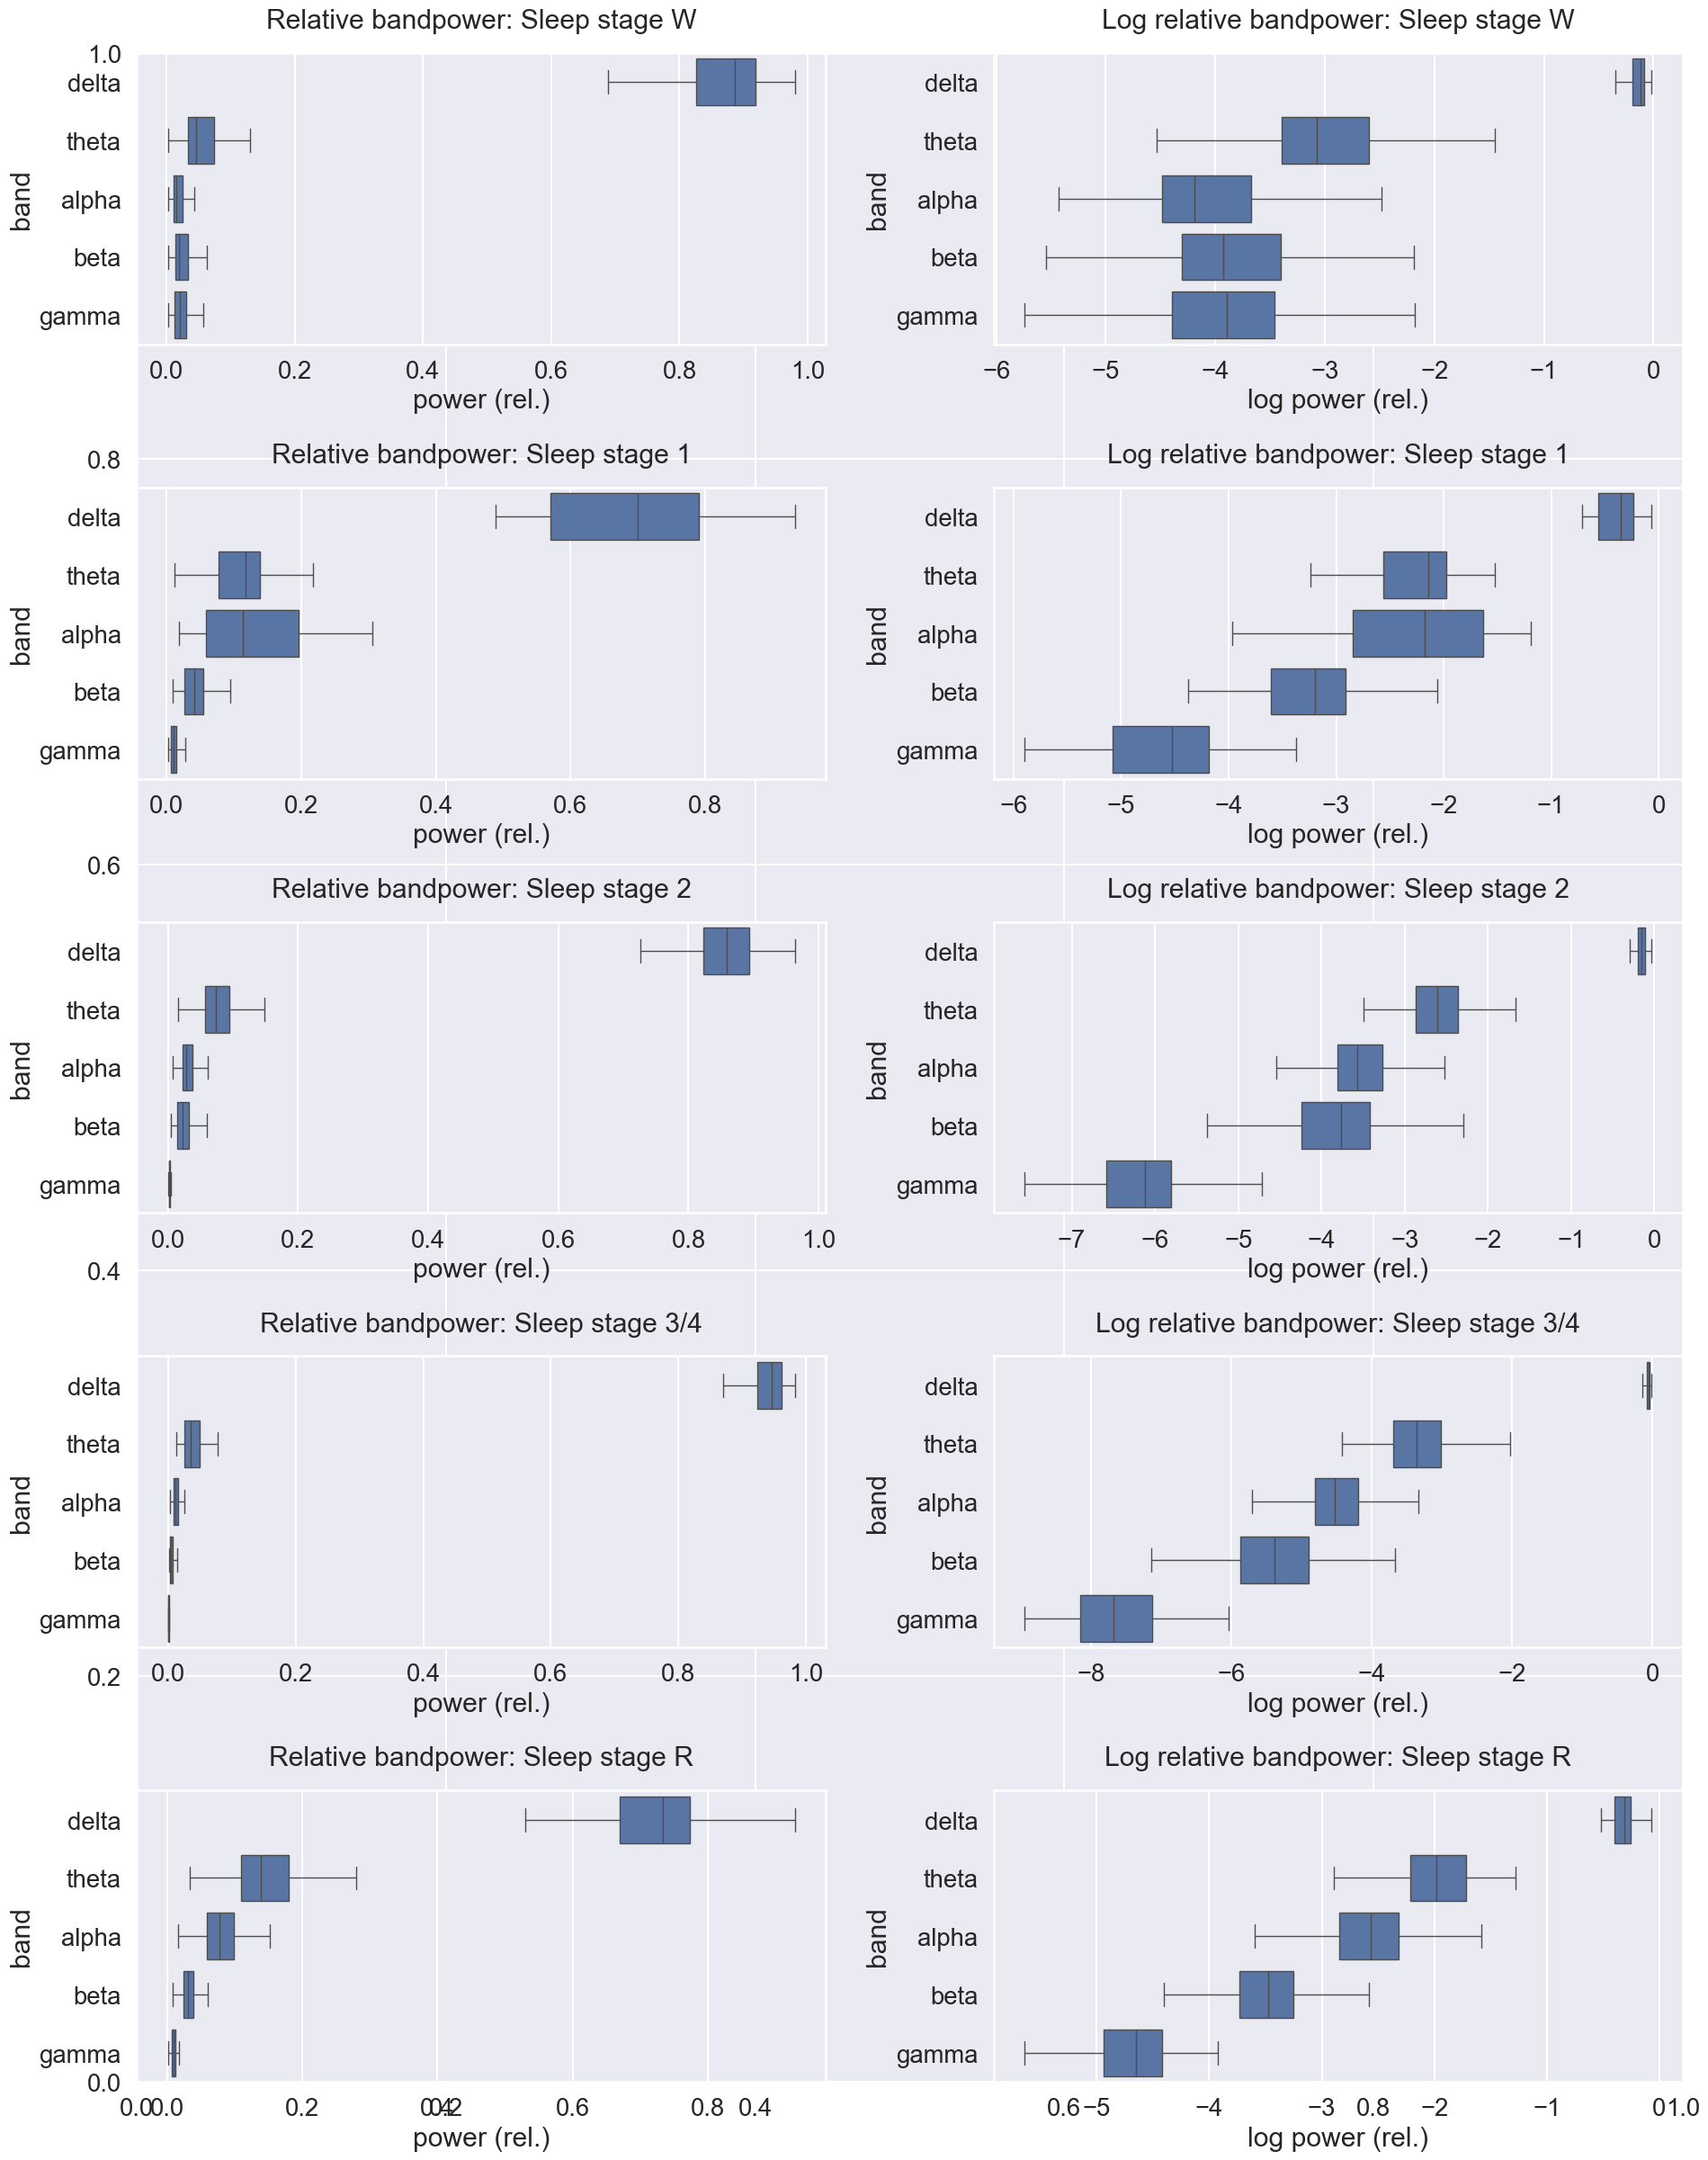

In [18]:
plt.rcParams["figure.figsize"] = (20,25)
plt.subplot()

nrows = len(consts.get_event_ids().keys())
ncols = 2
subplot_count = 1

for event, e_id  in consts.get_event_ids().items():
    sub_epoch_pow_rel_df = pd.DataFrame.from_dict(sleep_stage_rel_bandpower[event]).melt().rename(columns={'variable': 'band', 'value': 'power (rel.)'})
    sub_epoch_pow_log_rel_df = pd.DataFrame.from_dict(sleep_stage_rel_bandpower[event]).melt().rename(columns={'variable': 'band', 'value': 'log power (rel.)'})
    sub_epoch_pow_log_rel_df['log power (rel.)'] = np.log(sub_epoch_pow_log_rel_df['log power (rel.)'])

    # subplot_id = str(len(event_id.keys())) + "2" + str(subplot_count)
    plt.subplot(nrows, ncols, subplot_count)
    sns.boxplot(x='power (rel.)', y='band', data=sub_epoch_pow_rel_df, showfliers = False)# , scale="width")
    plt.title("Relative bandpower: " + event)

    subplot_count += 1

    # subplot_id = str(len(event_id.keys())) + "2" + str(subplot_count)
    plt.subplot(nrows, ncols, subplot_count)
    sns.boxplot(x='log power (rel.)', y='band', data=sub_epoch_pow_log_rel_df, showfliers = False) #, scale="width")
    plt.title("Log relative bandpower: " + event)

    subplot_count += 1

plt.tight_layout()

In [19]:
print(sleep_stage_rel_bandpower['Sleep stage W']['delta'][0])
print(sleep_stage_rel_bandpower['Sleep stage W']['theta'][0])
print(sleep_stage_rel_bandpower['Sleep stage W']['alpha'][0])

0.903198273737737
0.025885513966336895
0.009812470317050289


In [20]:
rel_bandpower_values_df = preprocess.bandpower_dict_to_df(sleep_stage_rel_bandpower, consts.get_event_ids())
rel_bandpower_values_df

,delta,theta,alpha,beta,gamma,Sleep Stage Class
0,0.90,0.03,9.81e-03,0.03,3.34e-02,0
1,0.92,0.02,1.13e-02,0.03,2.71e-02,0
2,0.90,0.04,1.24e-02,0.02,2.09e-02,0
3,0.83,0.09,2.23e-02,0.02,2.95e-02,0
4,0.81,0.10,2.79e-02,0.03,3.54e-02,0
...,...,...,...,...,...,...
1016,0.78,0.12,4.71e-02,0.03,1.33e-02,4
1017,0.71,0.15,7.15e-02,0.05,1.16e-02,4
1018,0.70,0.20,6.58e-02,0.02,5.50e-03,4
1019,0.64,0.15,1.30e-01,0.06,1.14e-02,4


In [21]:
log_rel_bandpower_values_df = preprocess.log_rel_bandpowers(rel_bandpower_values_df)
log_rel_bandpower_values_df

,delta,theta,alpha,beta,gamma,Sleep Stage Class
0,-0.10,-3.65,-4.62,-3.66,-3.40,0
1,-0.09,-4.12,-4.48,-3.54,-3.61,0
2,-0.10,-3.23,-4.39,-3.84,-3.87,0
3,-0.19,-2.37,-3.80,-3.78,-3.52,0
4,-0.22,-2.32,-3.58,-3.52,-3.34,0
...,...,...,...,...,...,...
1016,-0.25,-2.14,-3.05,-3.40,-4.32,4
1017,-0.35,-1.88,-2.64,-2.96,-4.46,4
1018,-0.36,-1.63,-2.72,-3.70,-5.20,4
1019,-0.45,-1.92,-2.04,-2.75,-4.48,4


In [22]:
rel_bandpower_values_df #.iloc[0]

,delta,theta,alpha,beta,gamma,Sleep Stage Class
0,0.90,0.03,9.81e-03,0.03,3.34e-02,0
1,0.92,0.02,1.13e-02,0.03,2.71e-02,0
2,0.90,0.04,1.24e-02,0.02,2.09e-02,0
3,0.83,0.09,2.23e-02,0.02,2.95e-02,0
4,0.81,0.10,2.79e-02,0.03,3.54e-02,0
...,...,...,...,...,...,...
1016,0.78,0.12,4.71e-02,0.03,1.33e-02,4
1017,0.71,0.15,7.15e-02,0.05,1.16e-02,4
1018,0.70,0.20,6.58e-02,0.02,5.50e-03,4
1019,0.64,0.15,1.30e-01,0.06,1.14e-02,4


In [23]:
rel_bandpower_values_df['Sleep Stage Class'].value_counts()

Sleep Stage Class
0    368
2    250
3    220
4    125
1     58
Name: count, dtype: int64

Note that the dataset is significantly imbalanced. So let's use SMOTE to over-sample to avoid performance issues on the LightGBM.

In [24]:
rel_bandpower_values_df.columns

Index(['delta', 'theta', 'alpha', 'beta', 'gamma', 'Sleep Stage Class'], dtype='object')

In [25]:
NUM_CLASSES = len(rel_bandpower_values_df['Sleep Stage Class'].unique())
NUM_CLASSES

5

In [26]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

dataset_df = rel_bandpower_values_df

X_train, X_test, y_train, y_test = train_test_split(dataset_df[list(dataset_df.columns)[:-1]],
                                                  dataset_df[list(dataset_df.columns)[-1]],
                                                  test_size=0.33,
                                                  random_state=RAND_STATE_INT)

sm = SMOTE(random_state = RAND_STATE_INT)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

In [27]:
pd.DataFrame(y_train_smote).value_counts()

Sleep Stage Class
0                    246
1                    246
2                    246
3                    246
4                    246
Name: count, dtype: int64

Now our training dataset is balanced.

### Random Forest Classifier

Let's explore whether SMOTE improves performance at all for Random Forest.

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
y_pred = rf.predict(X_test)
y_pred.shape

(337,)

In [30]:
y_probs = rf.predict_proba(X_test)
y_probs.shape

(337, 5)

In [31]:
y_probs[:, 1]

array([0.18, 0.07, 0.85, 0.01, 0.03, 0.06, 0.07, 0.01, 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.04, 0.  , 0.01, 0.17, 0.  , 0.  , 0.01,
       0.34, 0.  , 0.21, 0.66, 0.  , 0.01, 0.08, 0.  , 0.  , 0.31, 0.69,
       0.  , 0.01, 0.03, 0.15, 0.01, 0.  , 0.48, 0.39, 0.  , 0.24, 0.  ,
       0.  , 0.03, 0.04, 0.  , 0.  , 0.  , 0.  , 0.  , 0.32, 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.01, 0.11, 0.28, 0.01, 0.  , 0.  , 0.  ,
       0.  , 0.4 , 0.  , 0.01, 0.29, 0.26, 0.39, 0.  , 0.  , 0.  , 0.  ,
       0.14, 0.  , 0.  , 0.  , 0.  , 0.01, 0.1 , 0.  , 0.  , 0.  , 0.02,
       0.  , 0.01, 0.16, 0.  , 0.08, 0.  , 0.25, 0.  , 0.04, 0.  , 0.04,
       0.41, 0.  , 0.  , 0.09, 0.14, 0.  , 0.  , 0.  , 0.  , 0.  , 0.02,
       0.  , 0.  , 0.  , 0.01, 0.23, 0.  , 0.  , 0.01, 0.  , 0.23, 0.  ,
       0.  , 0.02, 0.56, 0.09, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.06,
       0.  , 0.  , 0.  , 0.  , 0.21, 0.  , 0.26, 0.28, 0.  , 0.  , 0.38,
       0.  , 0.12, 0.  , 0.  , 0.35, 0.53, 0.02, 0.

In [32]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_probs, multi_class='ovo', average='macro')

np.float64(0.9638631474462203)

In [33]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Confusion Matrix\n", cm)
print("Confusion Matrix %\n", cm/np.sum(cm))

print("--WEIGHTED---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)


print("--MICRO---")
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
f1 = f1_score(y_test, y_pred, average='micro')
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)

print("--MACRO---")
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)

Confusion Matrix
 [[121   1   0   0   0]
 [  5   9   3   0   4]
 [  0   1  76   9   1]
 [  3   0   4  61   0]
 [  1   4   2   0  32]]
Confusion Matrix %
 [[0.35905045 0.00296736 0.         0.         0.        ]
 [0.0148368  0.02670623 0.00890208 0.         0.01186944]
 [0.         0.00296736 0.22551929 0.02670623 0.00296736]
 [0.00890208 0.         0.01186944 0.1810089  0.        ]
 [0.00296736 0.01186944 0.00593472 0.         0.09495549]]
--WEIGHTED---
Accuracy: 0.887240356083086
Precision: 0.8810948190944701
Recall: 0.887240356083086
f1 Score: 0.8827907963831042
--MICRO---
Precision: 0.887240356083086
Recall: 0.887240356083086
f1 Score: 0.887240356083086
--MACRO---
Precision: 0.8322360628242981
Recall: 0.802301913938598
f1 Score: 0.8140403249444812


<Axes: >

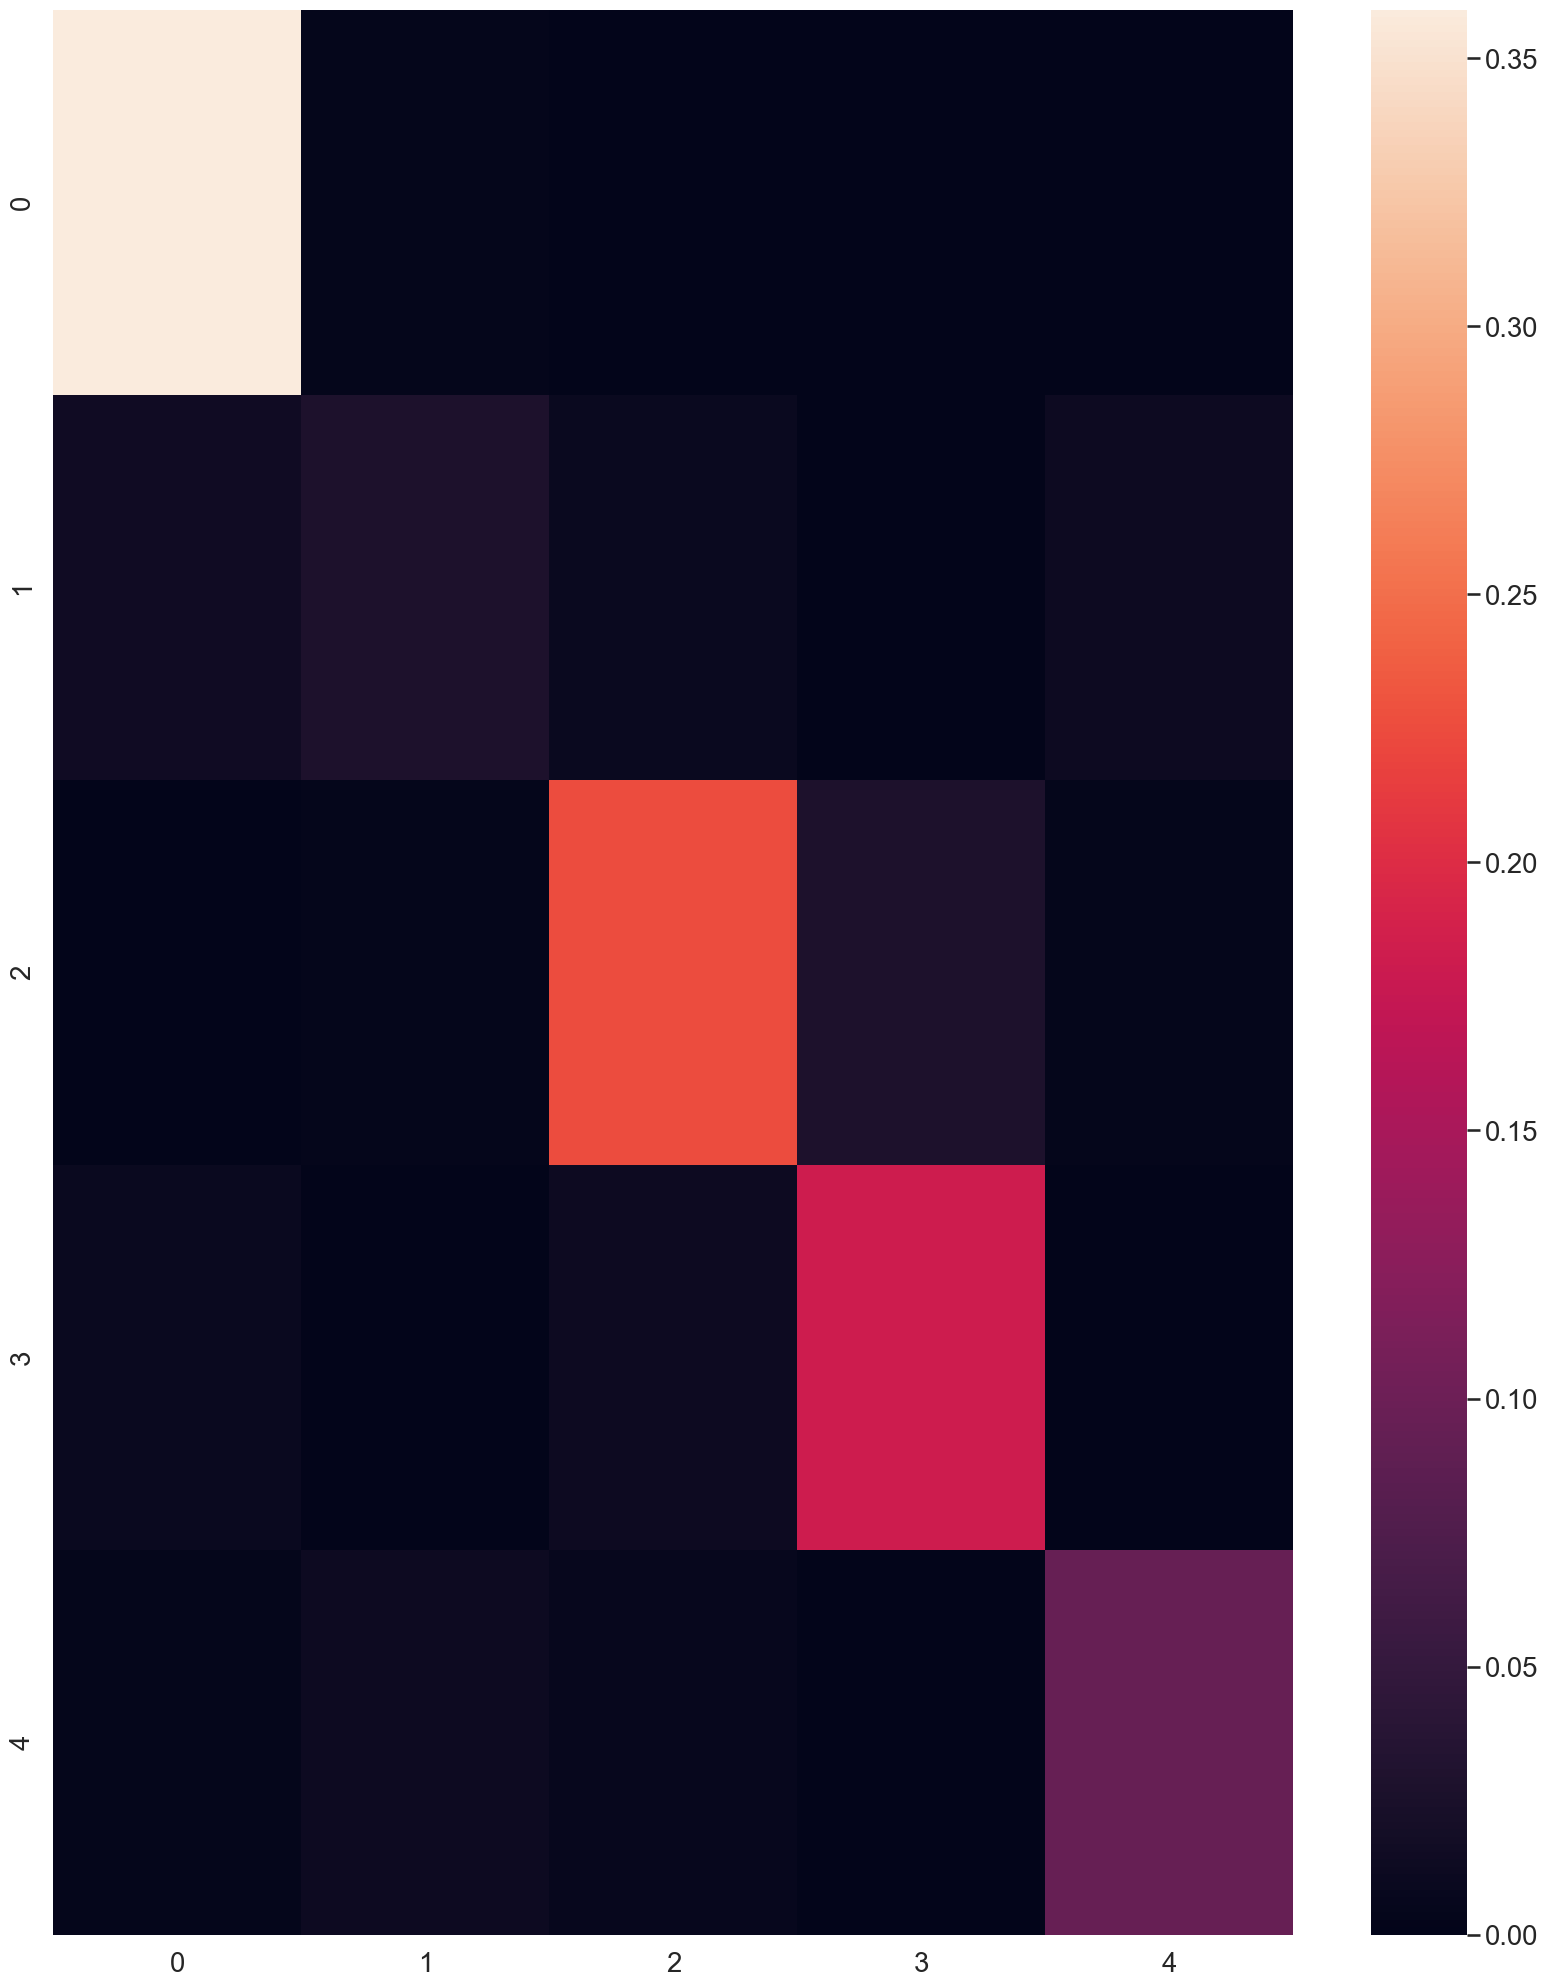

In [34]:
seaborn.heatmap(cm/np.sum(cm))

In [35]:
rf_smote = RandomForestClassifier()
rf_smote.fit(X_train_smote, y_train_smote)

y_pred = rf_smote.predict(X_test)

In [36]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Confusion Matrix\n", cm)
print("Confusion Matrix %\n", cm/np.sum(cm))

print("--WEIGHTED---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)


print("--MICRO---")
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
f1 = f1_score(y_test, y_pred, average='micro')
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)

print("--MACRO---")
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print("Precision:", precision)
print("Recall:", recall)
print("f1 Score:", f1)

Confusion Matrix
 [[115   6   0   1   0]
 [  1  14   1   0   5]
 [  0   6  69  11   1]
 [  3   0   5  60   0]
 [  0   7   2   0  30]]
Confusion Matrix %
 [[0.34124629 0.01780415 0.         0.00296736 0.        ]
 [0.00296736 0.04154303 0.00296736 0.         0.0148368 ]
 [0.         0.01780415 0.20474777 0.03264095 0.00296736]
 [0.00890208 0.         0.0148368  0.17804154 0.        ]
 [0.         0.02077151 0.00593472 0.         0.08902077]]
--WEIGHTED---
Accuracy: 0.8545994065281899
Precision: 0.8722135198832702
Recall: 0.8545994065281899
f1 Score: 0.8605740519806631
--MICRO---
Precision: 0.8545994065281899
Recall: 0.8545994065281899
f1 Score: 0.8545994065281899
--MACRO---
Precision: 0.7906799083269671
Recall: 0.8107953552338882
f1 Score: 0.7942963273537103


### Quadratic Discriminant Analysis

In [38]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qd = QuadraticDiscriminantAnalysis(reg_param=0.2)
qd.fit(X_train_smote, y_train_smote)

y_pred = qd.predict(X_test)

### LightGBM
Let's try to use a gradient boosting model:

In [41]:
import optuna.integration.lightgbm as lgb

from sklearn.model_selection import train_test_split, RepeatedKFold
from imblearn.over_sampling import SMOTE

import lightgbm as lgb
from lightgbm import early_stopping
# from lightgbm import log_evaluation

import optuna
import optuna.integration.lightgbm as optuna_lgb

datasets_dfs = {"Relative Bandpower": rel_bandpower_values_df,
                "Log Relative Bandpower": log_rel_bandpower_values_df}

for feature_type, dataset_df in datasets_dfs.items():
    X_train, X_test, y_train, y_test = train_test_split(dataset_df[list(dataset_df.columns)[:-1]],
                                                      dataset_df[list(dataset_df.columns)[-1]],
                                                      test_size=0.33,
                                                      random_state=RAND_STATE_INT)
    
    sm = SMOTE(random_state = RAND_STATE_INT)
    X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)
    
    d_train = lgb.Dataset(X_train_smote, label=y_train_smote)
    d_test = lgb.Dataset(X_test, label=y_test)

    
    rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RAND_STATE_INT)

    params = {
            "objective": "multiclass",
            "num_classes": NUM_CLASSES,
            "metric": "multi_logloss",
            "verbosity": -1,
            "boosting_type": "gbdt",                
            "seed": RAND_STATE_INT
        }
    
    study_tuner = optuna.create_study(direction='minimize')

    # Suppress information only outputs - otherwise optuna is 
    # quite verbose, which can be nice, but takes up a lot of space
    optuna.logging.set_verbosity(optuna.logging.WARNING) 
    
    # Run optuna LightGBMTunerCV tuning of LightGBM with cross-validation
    tuner = optuna_lgb.LightGBMTunerCV(params, 
                                       d_train,
                                       study=study_tuner,
                                       verbose_eval=False,                            
                                       early_stopping_rounds=10,
                                       time_budget=900, # in seconds -> 1 hours
                                       seed = RAND_STATE_INT,
                                       folds=rkf,
                                       num_boost_round=50,
    #                                    callbacks=[
    #                                        optuna_lgb.reset_parameter(
    #                                            learning_rate = [0.09]*100 + \
    #                                                            [0.05]*50 + \
    #                                                            [0.01]*30 + \
    #                                                            [0.005]*20
    #                                    )]
    )
    
    tuner.run()

    evals={}
    model = lgb.train(tuner.best_params,
                      train_set = d_train, 
                      valid_sets=[d_train, d_test],
                      callbacks = [lgb.record_evaluation(evals)],
                      verbose_eval=False,
                      num_boost_round=100)

    y_score = model.predict(X_test)

    y_pred = np.argmax(y_score, axis=1)

    cm = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print("---------------------" + feature_type + "---------------------")
    print("Confusion Matrix\n", cm)
    print("Confusion Matrix %\n", cm/np.sum(cm))
    
    print("--WEIGHTED---")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("f1 Score:", f1)
    
    
    print("--MICRO---")
    precision = precision_score(y_test, y_pred, average='micro')
    recall = recall_score(y_test, y_pred, average='micro')
    f1 = f1_score(y_test, y_pred, average='micro')
    print("Precision:", precision)
    print("Recall:", recall)
    print("f1 Score:", f1)
    
    print("--MACRO---")
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    print("Precision:", precision)
    print("Recall:", recall)
    print("f1 Score:", f1)

[I 2025-08-13 17:34:53,142] A new study created in memory with name: no-name-2b86d6cc-d04c-48b6-87d2-d99a87658a24
feature_fraction, val_score: inf:   0%|          | 0/7 [00:00<?, ?it/s]

---------------------Relative Bandpower---------------------
Confusion Matrix
 [[115   6   0   0   1]
 [  2  14   2   0   3]
 [  0   1  75  10   1]
 [  3   0   4  61   0]
 [  0   7   0   0  32]]
Confusion Matrix %
 [[0.34124629 0.01780415 0.         0.         0.00296736]
 [0.00593472 0.04154303 0.00593472 0.         0.00890208]
 [0.         0.00296736 0.22255193 0.02967359 0.00296736]
 [0.00890208 0.         0.01186944 0.1810089  0.        ]
 [0.         0.02077151 0.         0.         0.09495549]]
--WEIGHTED---
Accuracy: 0.8813056379821959
Precision: 0.8905771132439749
Recall: 0.8813056379821959
f1 Score: 0.884731582054243
--MICRO---
Precision: 0.8813056379821959
Recall: 0.8813056379821959
f1 Score: 0.8813056379821959
--MACRO---
Precision: 0.8216558107403179
Recall: 0.8377860454091625
f1 Score: 0.8269004084621446


min_data_in_leaf, val_score: 0.344386: 100%|##########| 5/5 [00:34<00:00,  6.81s/it]


---------------------Log Relative Bandpower---------------------
Confusion Matrix
 [[114   7   0   0   1]
 [  2  12   3   0   4]
 [  0   4  73  10   0]
 [  3   0   7  58   0]
 [  0   6   1   0  32]]
Confusion Matrix %
 [[0.33827893 0.02077151 0.         0.         0.00296736]
 [0.00593472 0.03560831 0.00890208 0.         0.01186944]
 [0.         0.01186944 0.21661721 0.02967359 0.        ]
 [0.00890208 0.         0.02077151 0.17210682 0.        ]
 [0.         0.01780415 0.00296736 0.         0.09495549]]
--WEIGHTED---
Accuracy: 0.857566765578635
Precision: 0.869140882311924
Recall: 0.857566765578635
f1 Score: 0.8623795078767755
--MICRO---
Precision: 0.857566765578635
Recall: 0.857566765578635
f1 Score: 0.857566765578635
--MACRO---
Precision: 0.7917259914217318
Recall: 0.8036778515380585
f1 Score: 0.7949811401010867


Tuning hyperparameters using k-fold cross-validation:

In [42]:
# params = {
#     "objective": "binary",
#     "metric": "binary_logloss",
#     "verbosity": -1,
#     "boosting_type": "gbdt",
#     "num_leaves": 31,
#     "max_depth": -1,
#     "learning_rate": 0.1,
#     "n_estimators": 100,
#     "subsample_for_bin": 200000,
# #     sample_pos_weight 
#     "min_split_gain": 0.0,
#     "min_child_weight": 0.001,
#     "min_child_samples": 20,
#     "colsample_bytree": 1.0,
#     "reg_alpha": 0.0,
#     "reg_lambda": 0.0
# }

In [43]:


# rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RAND_STATE_INT)
# # rkf = RepeatedKFold(n_splits=2, n_repeats=2, random_state=RAND_STATE_INT)

# params = {
#         "objective": "multiclass",
#         "num_classes": NUM_CLASSES,
#         "metric": "multi_logloss",
#         "verbosity": -1,
#         "boosting_type": "gbdt",                
#         "seed": RAND_STATE_INT
#     }

# study_tuner = optuna.create_study(direction='minimize')

# # Suppress information only outputs - otherwise optuna is 
# # quite verbose, which can be nice, but takes up a lot of space
# optuna.logging.set_verbosity(optuna.logging.WARNING) 

# # Run optuna LightGBMTunerCV tuning of LightGBM with cross-validation
# tuner = optuna_lgb.LightGBMTunerCV(params, 
#                                    d_train,
#                                    study=study_tuner,
#                                    verbose_eval=False,                            
#                                    early_stopping_rounds=10,
#                                    time_budget=1800, # in seconds -> 2 hours
#                                    seed = RAND_STATE_INT,
#                                    folds=rkf,
#                                    num_boost_round=50,
# #                                    callbacks=[
# #                                        optuna_lgb.reset_parameter(
# #                                            learning_rate = [0.09]*100 + \
# #                                                            [0.05]*50 + \
# #                                                            [0.01]*30 + \
# #                                                            [0.005]*20
# #                                    )]
# )

# tuner.run()

In [44]:
# tuner.best_params

In [45]:
# import lightgbm as lgb

# evals={}
# model = lgb.train(tuner.best_params,
#                   train_set = d_train, 
#                   valid_sets=[d_train, d_test],
#                   callbacks = [lgb.record_evaluation(evals)],
#                   verbose_eval=False,
#                   num_boost_round=100)

In [46]:
# y_score = model.predict(X_test)

In [47]:
# y_pred = np.argmax(y_score, axis=1)
# y_pred.shape

In [48]:
# unique_values, counts = np.unique(y_pred, return_counts=True)
# counts

In [49]:
# cm = confusion_matrix(y_test, y_pred)
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred, average='weighted')
# recall = recall_score(y_test, y_pred, average='weighted')
# f1 = f1_score(y_test, y_pred, average='weighted')

# print("Confusion Matrix\n", cm)
# print("Confusion Matrix %\n", cm/np.sum(cm))

# print("--WEIGHTED---")
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("f1 Score:", f1)


# print("--MICRO---")
# precision = precision_score(y_test, y_pred, average='micro')
# recall = recall_score(y_test, y_pred, average='micro')
# f1 = f1_score(y_test, y_pred, average='micro')
# print("Precision:", precision)
# print("Recall:", recall)
# print("f1 Score:", f1)

# print("--MACRO---")
# precision = precision_score(y_test, y_pred, average='macro')
# recall = recall_score(y_test, y_pred, average='macro')
# f1 = f1_score(y_test, y_pred, average='macro')
# print("Precision:", precision)
# print("Recall:", recall)
# print("f1 Score:", f1)

In [50]:
# seaborn.heatmap(cm/np.sum(cm))

### Simple Feed-forward Neural Network
(Coming soon!)

In [51]:
# import torch
# import torch.nn as nn
# import pytorch_lightning as pl

In [52]:
# class TabularDataset(torch.utils.data.Dataset):
    
#     def __init__(self, df, feature_cols, class_col):
#         self.df = df
#         self.feature_cols = feature_cols
#         self.class_col = class_col
    
#     def __len__(self):
#         return len(self.df)
        
#     def __getitem__(self, idx):
#         return (torch.DoubleTensor(self.df[self.feature_cols].iloc[idx].tolist()),
#                torch.FloatTensor(self.df[self.class_col].iloc[idx].tolist()))

In [53]:
# # rel_bandpower_values_df.columns[:-2].tolist()
# rel_bp_dataset = TabularDataset(rel_bandpower_values_df,
#                                 rel_bandpower_values_df.columns[:-2].tolist(),
#                                 rel_bandpower_values_df.columns[-1])

# row, target = rel_bp_dataset.__getitem__(100)
# print("Row, target:", row, target)
# print("Row sample value:", row.numpy()[0])
# print("Types:", type(row), type(target))

In [54]:
# class BasicModel(pl.LightningModule):
    
#     def __init__(self):
#         super.__init__()
        
#         model = nn.Sequential(
#             nn.Linear(5, 5), # 5 bandpower features
#             nn.ReLU(),
#             nn.Linear(5,5),
#             nn.ReLU(),
#             nn.LogSoftmax()
#         )
    
#     def forward(x):
#         return self.model(x)
    
#     def training_step(self, batch, batch_idx):
        